In [1]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pathlib import Path
# read in all the data for yellow taxis
spark = SparkSession.builder.appName("Read Parquet").getOrCreate()
YELLOW_DIR = Path('data/year-2026-yellow/')
# read in all the data across the times
from pathlib import Path

data_root = Path("data")
pattern = "year-*-yellow"  # matches year-2026-yellow, year-2025-yellow, etc.
dirs = sorted([d for d in data_root.glob(pattern) if d.is_dir()])

parquet_files = []
for d in dirs:
    parquet_files.extend(sorted([p for p in d.glob("*.parquet") if p.is_file()]))

if not parquet_files:
    raise FileNotFoundError(f"No parquet files found under {data_root}/{pattern}")

yellow_data = None
for p in parquet_files:
    df = spark.read.parquet(str(p))
    if yellow_data is None:
        yellow_data = df
    else:
        # use unionByName to be robust to column ordering / missing columns
        yellow_data = yellow_data.unionByName(df, allowMissingColumns=True)

# yellow_data is the big row-wise union of all parquet files
print(f"Combined {len(parquet_files)} parquet files into dataframe with {yellow_data.count()} rows")
yellow_data.printSchema()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/08/22 23:32:36 WARN Utils: Your hostname, aydin-khan-desktop, resolves to a loopback address: 127.0.1.1; using 192.168.1.18 instead (on interface wlp11s0)
26/08/22 23:32:36 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/08/22 23:32:37 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where app

Combined 41 parquet files into dataframe with 147201830 rows
root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



# Cleaning the dataset

In [17]:
# get rid of rows where passenger count is 0 or null
yellow_data = yellow_data.filter((F.col("passenger_count") > 0) & (F.col("passenger_count").isNotNull()))
# get rid of rows where trip distance is 0, null or greater than 25
yellow_data = yellow_data.filter((F.col("trip_distance") > 0) & (F.col("trip_distance").isNotNull()) & (F.col("trip_distance") <= 25))
# get rid of rows where the trip duration is 0, null, less than 60 seconds or greater than 10000 seconds
yellow_data = yellow_data.filter((F.col("tpep_dropoff_datetime").isNotNull()) & (F.col("tpep_pickup_datetime").isNotNull()))
yellow_data = yellow_data.withColumn("trip_duration", F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime"))
yellow_data = yellow_data.filter((F.col("trip_duration") > 60) & (F.col("trip_duration").isNotNull()) & (F.col("trip_duration") < 10000))
yellow_data = yellow_data.filter(~F.col("PULocationID").isin([264, 265, 103, 104, 110]))
# get rid of rows where payment_type is null or not in the array [5, 6]
yellow_data = yellow_data.filter((F.col("payment_type").isNotNull()) & (~F.col("payment_type").isin([5, 6])))
print(yellow_data.count())

120193261


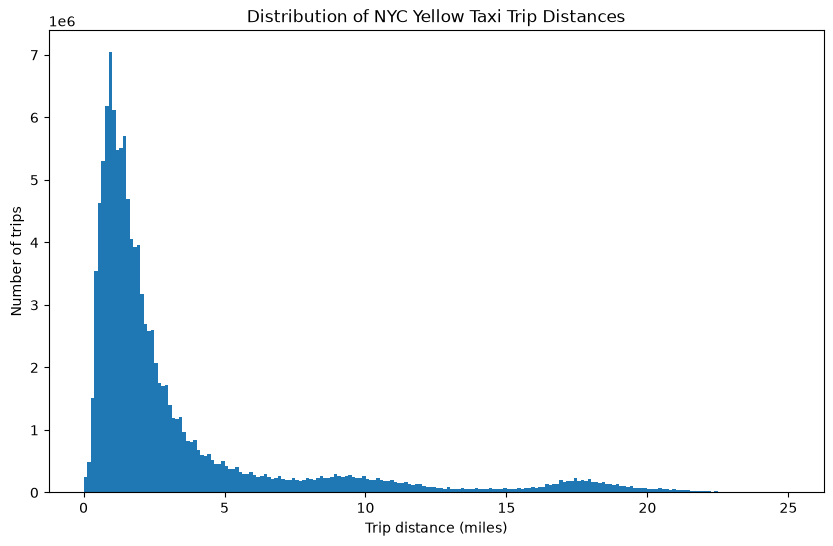

In [18]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

# Remove invalid/extreme trip distances
filtered_distance = yellow_data.filter(
    (F.col("trip_distance") > 0) &
    (F.col("trip_distance") <= 50)
)

# Calculate histogram in Spark
distances = (
    filtered_distance
    .select("trip_distance")
    .rdd
    .map(lambda row: float(row[0]))
)

bins, counts = distances.histogram(200)

# Plot the histogram
plt.figure(figsize=(10, 6))

plt.bar(
    bins[:-1],
    counts,
    width=bins[1] - bins[0],
    align="edge"
)

plt.xlabel("Trip distance (miles)")
plt.ylabel("Number of trips")
plt.title("Distribution of NYC Yellow Taxi Trip Distances")

plt.show()

# Calculating trip duration and revenue per minute

In [41]:
import geopandas as gpd
taxi_zones = gpd.read_file('data/taxi_zones/taxi_zones.shp')
data_zone_ids = {
    row["PULocationID"]
    for row in yellow_data.select("PULocationID").distinct().collect()
}

taxi_zones = taxi_zones[taxi_zones["OBJECTID"].isin(data_zone_ids)]
print(taxi_zones.dtypes)
taxi_zones.head()

OBJECTID         int32
Shape_Leng     float64
Shape_Area     float64
zone               str
LocationID       int32
borough            str
geometry      geometry
dtype: object


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


In [ ]:
daily_aggregated_data = yellow_data
daily_aggregated_data = (
    yellow_data
    .groupBy(
        F.to_date("tpep_pickup_datetime").alias("date"),
        "PULocationID"
    )
    .agg(
        F.sum("total_amount").alias("daily_revenue")
    )
    .orderBy("date", "PULocationID")
).sort('PULocationID', 'date')
print(daily_aggregated_data.count())
daily_aggregated_data.show()

36462
+----------+------------+------------------+
|      date|PULocationID|     daily_revenue|
+----------+------------+------------------+
|2026-01-01|           1|3848.2300000000005|
|2026-01-02|           1|           3044.13|
|2026-01-03|           1|2981.3399999999997|
|2026-01-04|           1| 4814.719999999999|
|2026-01-05|           1|2216.2799999999997|
|2026-01-06|           1|2014.4499999999998|
|2026-01-07|           1|            723.88|
|2026-01-08|           1|            587.96|
|2026-01-09|           1| 802.8199999999999|
|2026-01-10|           1|            885.02|
|2026-01-11|           1|             809.4|
|2026-01-12|           1|           1045.06|
|2026-01-13|           1|           1406.75|
|2026-01-14|           1|           1382.54|
|2026-01-15|           1|           2014.62|
|2026-01-16|           1|            1414.9|
|2026-01-17|           1|1278.1000000000001|
|2026-01-18|           1|1118.5900000000001|
|2026-01-19|           1|2250.8100000000004|
|202

In [6]:
def calculate_expected_daily_revenue(
    aggregated_data,
    geospatial_data
):
    """
    Calculate expected daily revenue for every location based on
    the average daily revenue of its geographic neighbors.

    If a location has no geographic neighbors, or no neighbor revenue
    for a particular date, the city-wide average revenue for that date
    is used as the fallback.

    Args:
        aggregated_data (Spark DataFrame):
            Spark DataFrame containing:
            [date, PULocationID, daily_revenue]

        geospatial_data (GeoDataFrame):
            GeoPandas GeoDataFrame containing:
            [OBJECTID, geometry]

    Returns:
        Spark DataFrame:
            The original aggregated_data with an additional column:
            [expected_daily_revenue]
    """

    # ---------------------------------------------------------
    # 1. Build geographic neighbor relationships once
    # ---------------------------------------------------------

    neighbor_rows = []

    for _, zone in geospatial_data.iterrows():

        location_id = zone["OBJECTID"]
        zone_geometry = zone["geometry"]

        neighbor_mask = geospatial_data.geometry.touches(zone_geometry)

        neighbor_ids = geospatial_data.loc[
            neighbor_mask,
            "OBJECTID"
        ].tolist()

        for neighbor_id in neighbor_ids:
            neighbor_rows.append(
                (location_id, neighbor_id)
            )

    neighbor_df = spark.createDataFrame(
        neighbor_rows,
        ["PULocationID", "neighbor_id"]
    )

    # ---------------------------------------------------------
    # 2. Calculate city-wide daily average once
    # ---------------------------------------------------------

    city_daily_avg = (
        aggregated_data
        .groupBy("date")
        .agg(
            F.avg("daily_revenue").alias("city_avg_daily_revenue")
        )
    )

    # ---------------------------------------------------------
    # 3. Get daily revenue for every location's neighbors
    # ---------------------------------------------------------

    neighbor_daily_revenue = (
        neighbor_df
        .join(
            aggregated_data,
            neighbor_df["neighbor_id"]
            == aggregated_data["PULocationID"],
            "inner"
        )
        .groupBy(
            neighbor_df["PULocationID"],
            aggregated_data["date"]
        )
        .agg(
            F.avg("daily_revenue").alias(
                "expected_daily_revenue"
            )
        )
    )

    # ---------------------------------------------------------
    # 4. Join expected revenue back onto original data
    # ---------------------------------------------------------

    result = (
        aggregated_data
        .join(
            neighbor_daily_revenue,
            on=["PULocationID", "date"],
            how="left"
        )
        .join(
            city_daily_avg,
            on="date",
            how="left"
        )
        .withColumn(
            "expected_daily_revenue",
            F.coalesce(
                F.col("expected_daily_revenue"),
                F.col("city_avg_daily_revenue")
            )
        )
        .drop("city_avg_daily_revenue")
        .orderBy("PULocationID", "date")
    )

    return result

In [7]:
performance_stats = calculate_expected_daily_revenue(daily_aggregated_data, taxi_zones)
performance_stats.show()

+----------+------------+------------------+----------------------+
|      date|PULocationID|     daily_revenue|expected_daily_revenue|
+----------+------------+------------------+----------------------+
|2026-01-01|           1|3848.2300000000005|    14631.448739837419|
|2026-01-02|           1|           3044.13|    12268.054916666699|
|2026-01-03|           1|2981.3399999999997|    12949.578535564891|
|2026-01-04|           1| 4814.719999999999|    11699.707489539795|
|2026-01-05|           1|2216.2799999999997|    11978.354669421538|
|2026-01-06|           1|2014.4499999999998|    12611.949753086434|
|2026-01-07|           1|            723.88|     13330.01925000001|
|2026-01-08|           1|            587.96|    14250.586348547735|
|2026-01-09|           1| 802.8199999999999|    14624.093958333358|
|2026-01-10|           1|            885.02|    16424.189958159015|
|2026-01-11|           1|             809.4|    13611.619663865573|
|2026-01-12|           1|           1045.06|    

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


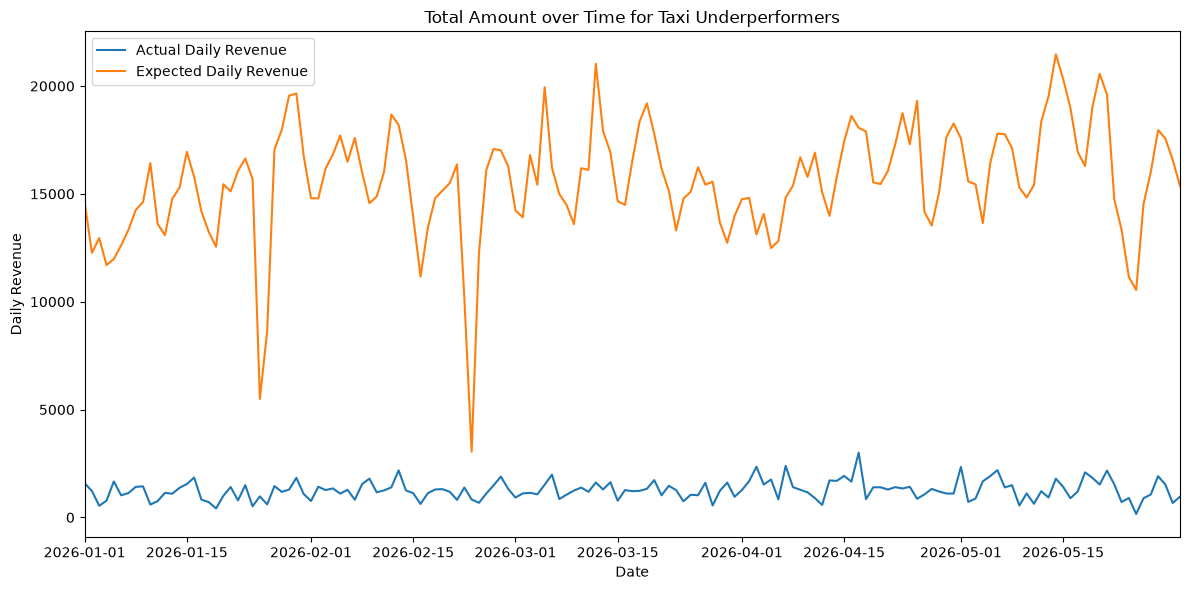

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
expected_performance = performance_stats.filter(F.col("PULocationID") == 119)  # Example PULocationID
# Convert PySpark DataFrame to Pandas for plotting
taxi_underperformers_sub = expected_performance.select("date", "daily_revenue", 'expected_daily_revenue') \
    .orderBy("date") \
    .toPandas()

# Plot

plt.figure(figsize=(12, 6))
plt.plot(taxi_underperformers_sub["date"], taxi_underperformers_sub["daily_revenue"], label="Actual Daily Revenue")
plt.plot(taxi_underperformers_sub["date"], taxi_underperformers_sub["expected_daily_revenue"], label="Expected Daily Revenue")
plt.xlim(pd.Timestamp('2026-01-01'), pd.Timestamp('2026-05-31'))
plt.xlabel("Date")
plt.ylabel("Daily Revenue")
plt.title("Total Amount over Time for Taxi Underperformers")
plt.legend()
plt.tight_layout()
plt.show()

# Calculating underperformance to identify underperforming taxi zones

In [9]:
minutes_per_day = 24 * 60

revenue_per_min_df = (
    performance_stats
    .groupBy("PULocationID")
    .agg(
        (F.sum(F.coalesce(F.col("daily_revenue"), F.lit(0.0))) / F.lit(float(minutes_per_day))).alias("revenue_per_min"),
        (F.sum(F.coalesce(F.col("expected_daily_revenue"), F.lit(0.0))) / F.lit(float(minutes_per_day))).alias("expected_revenue_per_min")
    )
    .orderBy("PULocationID")
)
print(revenue_per_min_df.count())
revenue_per_min_df.show()

260


+------------+------------------+------------------------+
|PULocationID|   revenue_per_min|expected_revenue_per_min|
+------------+------------------+------------------------+
|           1| 175.1679583333333|      1634.2134980416597|
|           2|1.7620694444444445|       8817.435840277862|
|           3| 61.04570833333334|      150.05107465277777|
|           4|1550.2027847222228|        4972.88015972222|
|           5|0.5002291666666666|       134.6347528865189|
|           6| 9.665187499999995|       287.4771899655823|
|           7| 982.1182152777776|       218.0837638888887|
|           8| 7.954381944444444|      1238.0513121924514|
|           9| 22.78847916666667|        48.3084658564815|
|          10|418.14806944444473|       206.3424930555555|
|          11|41.673006944444445|       250.2262916666667|
|          12|106.82911111111108|      2786.6290277777775|
|          13| 2788.796194444444|       110.6441008709981|
|          14|250.79528472222225|       68.1041770833333

In [ ]:
revenue_per_min_df = revenue_per_min_df.withColumn(
    "underperformance_per_min",
    (F.col("expected_revenue_per_min") - F.col("revenue_per_min")) / F.col("expected_revenue_per_min") * 100  # Convert to percentage
)
# Count instances per PULocationID in the raw trip data
location_counts_df = (
    yellow_data
    .groupBy("PULocationID")
    .agg(F.count("*").alias("instance_count"))
)

# Keep only locations with at least 5000 instances
revenue_per_min_df_filtered = (
    revenue_per_min_df
    .join(location_counts_df, on="PULocationID", how="inner")
    .filter(F.col("instance_count") >= 5000)
    .drop("instance_count")
)
revenue_per_min_df_filtered.sort('underperformance_per_min', ascending=False).show()

+------------+------------------+------------------------+------------------------+
|PULocationID|   revenue_per_min|expected_revenue_per_min|underperformance_per_min|
+------------+------------------+------------------------+------------------------+
|         119|132.46936805555552|      1634.2134980416597|       91.89399865964278|
|         117|193.62297916666657|      1634.2134980416597|        88.1519165397488|
|          86|205.84509027777779|      1634.2134980416597|       87.40402704270586|
|          55| 244.5362777777778|      1634.2134980416597|       85.03645465719045|
|         224| 916.6445208333334|       5218.176225694446|       82.43362276038609|
|         193|257.99575694444434|      1091.7531944444452|       76.36867395879439|
|         209| 876.0143472222215|       3436.477076388889|       74.50836051719708|
|         232| 1303.378006944444|        4991.65637847222|       73.88886757979594|
|         125|1784.3965625000003|       6399.183968750002|       72.11524826

In [11]:
# calculate percentage underperformance for location 119 
performance_stats_more = performance_stats
performance_stats_more = performance_stats_more.withColumn(
    "underperformance_percentage",
    (F.col("expected_daily_revenue") - F.col("daily_revenue")) / F.col("expected_daily_revenue") * 100  # Convert to percentage
)
performance_stats_more.show()

+----------+------------+------------------+----------------------+---------------------------+
|      date|PULocationID|     daily_revenue|expected_daily_revenue|underperformance_percentage|
+----------+------------+------------------+----------------------+---------------------------+
|2026-01-01|           1|3848.2300000000005|    14631.448739837419|          73.69891342664978|
|2026-01-02|           1|           3044.13|    12268.054916666699|          75.18653102975263|
|2026-01-03|           1|2981.3399999999997|    12949.578535564891|          76.97732021307095|
|2026-01-04|           1| 4814.719999999999|    11699.707489539795|          58.84751815970927|
|2026-01-05|           1|2216.2799999999997|    11978.354669421538|          81.49762583288887|
|2026-01-06|           1|2014.4499999999998|    12611.949753086434|          84.02744984369275|
|2026-01-07|           1|            723.88|     13330.01925000001|           94.5695502277688|
|2026-01-08|           1|            587

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


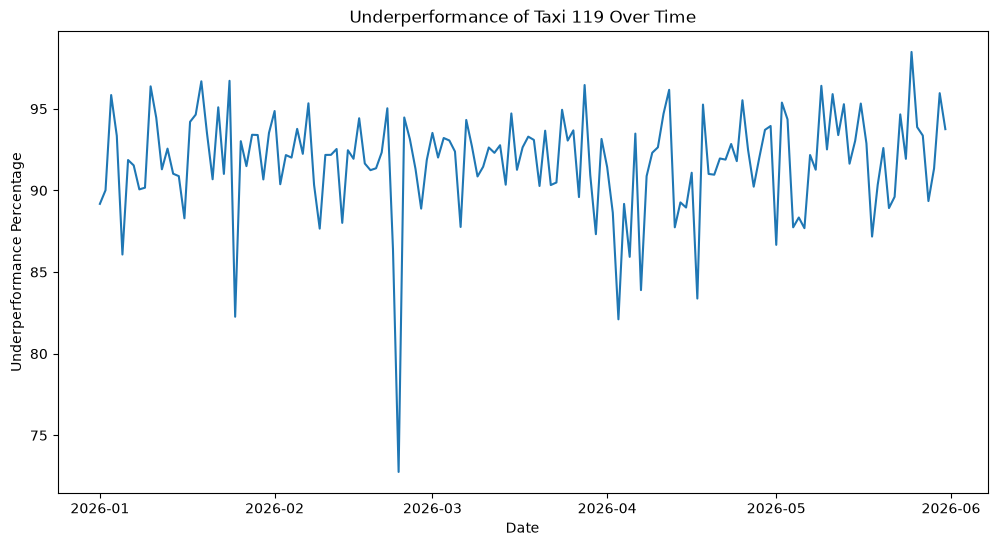

In [12]:
# make a line plot of the percentage underperformance over time for location 119
performance_stats_more_pd = performance_stats_more.filter(F.col('PULocationID') == 119).select("date", "underperformance_percentage").orderBy("date").toPandas()

plt.figure(figsize=(12, 6))
plt.plot(performance_stats_more_pd["date"], performance_stats_more_pd["underperformance_percentage"])
plt.xlabel("Date")
plt.ylabel("Underperformance Percentage")
plt.title("Underperformance of Taxi 119 Over Time")
plt.show()

In [ ]:
# calculate revenue per trip per day
num_trips = yellow_data.groupBy(F.to_date("tpep_pickup_datetime").alias("date"), "PULocationID").agg(F.count("*").alias("num_trips"))
num_trips = num_trips.sort('PULocationID', 'date')

In [14]:
performance_stats_more.show()

+----------+------------+------------------+----------------------+---------------------------+
|      date|PULocationID|     daily_revenue|expected_daily_revenue|underperformance_percentage|
+----------+------------+------------------+----------------------+---------------------------+
|2026-01-01|           1|3848.2300000000005|    14631.448739837419|          73.69891342664978|
|2026-01-02|           1|           3044.13|    12268.054916666699|          75.18653102975263|
|2026-01-03|           1|2981.3399999999997|    12949.578535564891|          76.97732021307095|
|2026-01-04|           1| 4814.719999999999|    11699.707489539795|          58.84751815970927|
|2026-01-05|           1|2216.2799999999997|    11978.354669421538|          81.49762583288887|
|2026-01-06|           1|2014.4499999999998|    12611.949753086434|          84.02744984369275|
|2026-01-07|           1|            723.88|     13330.01925000001|           94.5695502277688|
|2026-01-08|           1|            587

In [15]:
performance_stats_more = (
    performance_stats_more
    .join(num_trips, on=["date", "PULocationID"], how="left")
    .withColumn(
        "revenue_per_trip",
        F.when(F.col("num_trips") > 0, F.col("daily_revenue") / F.col("num_trips"))
         .otherwise(F.lit(None))
    )
)

In [16]:
performance_stats_more.filter(F.col('underperformance_percentage') < 95).sort('underperformance_percentage', ascending=False).show()

+----------+------------+------------------+----------------------+---------------------------+---------+------------------+
|      date|PULocationID|     daily_revenue|expected_daily_revenue|underperformance_percentage|num_trips|  revenue_per_trip|
+----------+------------+------------------+----------------------+---------------------------+---------+------------------+
|2026-01-28|         207|            463.63|              9264.735|          94.99575541016554|        8|          57.95375|
|2026-02-13|          96|             156.5|     3125.126666666667|          94.99220298270576|        3|52.166666666666664|
|2026-03-20|          57|             75.66|     1510.006666666667|          94.98942609524902|        1|             75.66|
|2026-05-05|          32|            822.26|      16402.8971729958|          94.98710507462246|       23| 35.75043478260869|
|2026-01-11|         185| 682.9200000000001|    13611.619663865573|          94.98281602877186|       22|31.041818181818186|


In [17]:
revenue_per_trip_overall = (
    performance_stats_more
    .groupBy("PULocationID")
    .agg(
        F.sum(F.coalesce(F.col("daily_revenue"), F.lit(0.0))).alias("total_revenue"),
        F.sum(F.coalesce(F.col("num_trips"), F.lit(0))).alias("total_trips")
    )
    .withColumn(
        "revenue_per_trip",
        F.when(F.col("total_trips") > 0, F.col("total_revenue") / F.col("total_trips"))
         .otherwise(F.lit(None))
    )
    .select("PULocationID", "revenue_per_trip")
    .orderBy("PULocationID")
)

In [18]:
revenue_per_trip_overall.sort('revenue_per_trip').show()

+------------+------------------+
|PULocationID|  revenue_per_trip|
+------------+------------------+
|         237| 21.94192241393329|
|         141|22.587853780083968|
|         236| 22.62067620759977|
|         263|23.375766788880856|
|         142|23.671890955701414|
|         238|   23.678219154218|
|         239|  23.7133999554863|
|         151|23.809487345180404|
|          43|24.035820814008915|
|         207|24.414652706843707|
|         229|24.486115409919314|
|         143| 24.63097982299628|
|         262|24.818311086091196|
|          90| 25.00878430225801|
|         107|25.072673519972593|
|         140| 25.11986771532527|
|         137|25.313198539327285|
|         113| 25.42622138845275|
|         234|25.434950804182126|
|          24|   25.520278562174|
+------------+------------------+
only showing top 20 rows


Next steps
- Get FHV data
- Show FHV demand increasing as yellow taxi demand decreases
- Then justify a course of action: Redirect yellow taxis to the zones where FHVs operate less frequently.
- Get data on employment density in the various zones
- Analyse the effect of employment density on taxi demand, controlling for subway station availability.

In [2]:
pattern = "year-*-fhvhv"  # matches year-2026-yellow, year-2025-yellow, etc.
dirs = sorted([d for d in data_root.glob(pattern) if d.is_dir()])

parquet_files = []
for d in dirs:
    parquet_files.extend(sorted([p for p in d.glob("*.parquet") if p.is_file()]))

if not parquet_files:
    raise FileNotFoundError(f"No parquet files found under {data_root}/{pattern}")

fhvhv_data = None
for p in parquet_files:
    df = spark.read.parquet(str(p))
    if fhvhv_data is None:
        fhvhv_data = df
    else:
        # use unionByName to be robust to column ordering / missing columns
        fhvhv_data = fhvhv_data.unionByName(df, allowMissingColumns=True)

# fhvhv_data is the big row-wise union of all parquet files
print(f"Combined {len(parquet_files)} parquet files into dataframe with {fhvhv_data.count()} rows")
fhvhv_data.printSchema()

Combined 29 parquet files into dataframe with 577956582 rows
root
 |-- hvfhs_license_num: string (nullable = true)
 |-- dispatching_base_num: string (nullable = true)
 |-- originating_base_num: string (nullable = true)
 |-- request_datetime: timestamp_ntz (nullable = true)
 |-- on_scene_datetime: timestamp_ntz (nullable = true)
 |-- pickup_datetime: timestamp_ntz (nullable = true)
 |-- dropoff_datetime: timestamp_ntz (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- trip_miles: double (nullable = true)
 |-- trip_time: long (nullable = true)
 |-- base_passenger_fare: double (nullable = true)
 |-- tolls: double (nullable = true)
 |-- bcf: double (nullable = true)
 |-- sales_tax: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- tips: double (nullable = true)
 |-- driver_pay: double (nullable = true)
 |-- shared_request_flag: string (nullable = true)
 |-- sha

In [ ]:
# data cleaning
# remove rows where driver_pay is null, less than or equal to 0
fhvhv_data = fhvhv_data.filter(fhvhv_data.driver_pay.isNotNull() & (fhvhv_data.driver_pay > 0))
# remove rows where trip time is null or less than 10 seconds
fhvhv_data = fhvhv_data.filter(fhvhv_data.trip_time.isNotNull() & (fhvhv_data.trip_time >= 10))
# remove rows where trip miles is null or 0
fhvhv_data = fhvhv_data.filter(fhvhv_data.trip_miles.isNotNull() & (fhvhv_data.trip_miles > 0))
# remove rows where PULocationID is in the list of invalid IDs
fhvhv_data = fhvhv_data.filter(~F.col("PULocationID").isin([264, 265, 103, 104, 110]))
# do the same for DOLocationID
fhvhv_data = fhvhv_data.filter(~F.col("DOLocationID").isin([264, 265, 103, 104, 110]))

577956582


In [10]:
fhvhv_data.select('trip_miles').describe().show()

+-------+-----------------+
|summary|       trip_miles|
+-------+-----------------+
|  count|        577956582|
|   mean|5.019588097351284|
| stddev|5.864159667478426|
|    min|              0.0|
|    max|          1644.54|
+-------+-----------------+



In [21]:
station_data = spark.read.csv('data/station_data.csv', header=True, inferSchema=True)
station_data.show()

+------------+----------+----------+--------+-------------------+--------------------+-------+-----+--------------+---------+-------------+--------------+---------------------+---------------------+---+--------------+--------------+-----------+--------------------+
|GTFS Stop ID|Station ID|Complex ID|Division|               Line|           Stop Name|Borough|  CBD|Daytime Routes|Structure|GTFS Latitude|GTFS Longitude|North Direction Label|South Direction Label|ADA|ADA Northbound|ADA Southbound|  ADA Notes|        Georeference|
+------------+----------+----------+--------+-------------------+--------------------+-------+-----+--------------+---------+-------------+--------------+---------------------+---------------------+---+--------------+--------------+-----------+--------------------+
|         R01|         1|         1|     BMT|            Astoria|Astoria-Ditmars Blvd|      Q|false|           N W| Elevated|    40.775036|    -73.912034|            Last Stop|            Manhattan|  0|

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


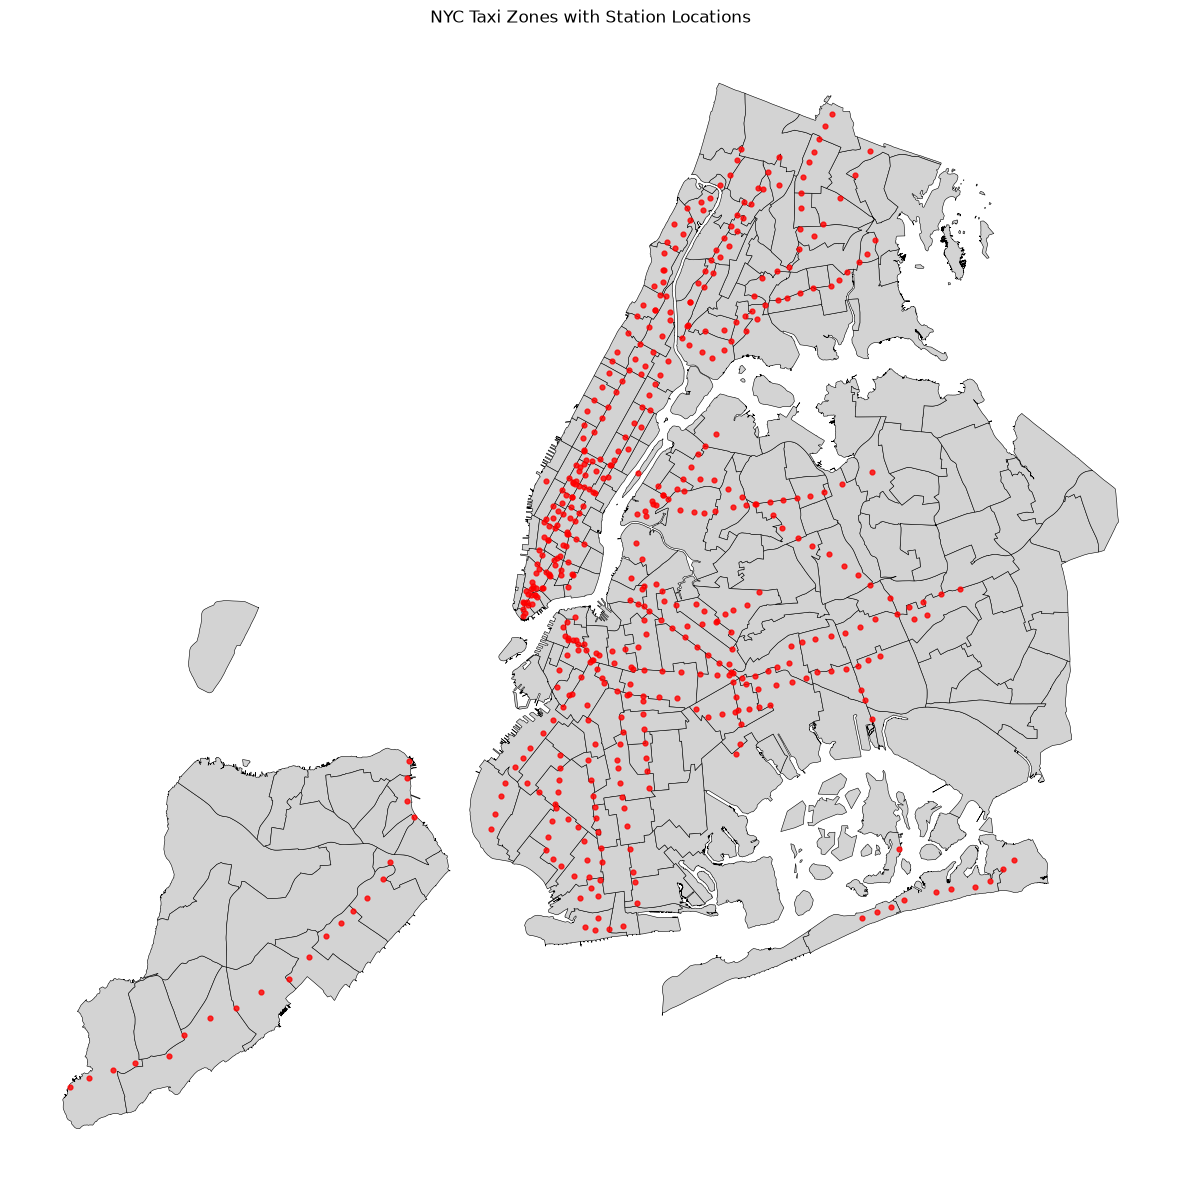

In [22]:
# Convert Spark DF -> Pandas
station_pd = station_data.toPandas()

lon_col = 'GTFS Longitude'
lat_col = 'GTFS Latitude'

if lon_col not in station_pd.columns or lat_col not in station_pd.columns:
    raise ValueError(f"Could not find lon/lat columns in station_data. Columns: {station_pd.columns.tolist()}")

# Build station GeoDataFrame (assume WGS84 input), then align CRS to taxi zones
station_gdf = gpd.GeoDataFrame(
    station_pd,
    geometry=gpd.points_from_xy(station_pd[lon_col], station_pd[lat_col]),
    crs="EPSG:4326"
).to_crs(taxi_zones.crs)

# Plot taxi zones + station points
fig, ax = plt.subplots(figsize=(12, 12))
taxi_zones.plot(ax=ax, color="lightgray", edgecolor="black", linewidth=0.4)
station_gdf.plot(ax=ax, color="red", markersize=12, alpha=0.8)

ax.set_title("NYC Taxi Zones with Station Locations")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [23]:
station_gdf = gpd.GeoDataFrame(
    station_pd,
    geometry=gpd.points_from_xy(
        station_pd["GTFS Longitude"],
        station_pd["GTFS Latitude"]
    ),
    crs="EPSG:4326"
).to_crs(taxi_zones.crs)

# 3) Keep taxi zone id + geometry (OBJECTID corresponds to PULocationID)
zones_gdf = taxi_zones[["OBJECTID", "geometry"]].copy()

# 4) Spatial join: station point within taxi zone polygon
stations_with_zone = gpd.sjoin(
    station_gdf,
    zones_gdf,
    how="left",
    predicate="within"
)

# 5) Count stations per zone, include zones with zero stations
station_counts_pd = (
    zones_gdf[["OBJECTID"]]
    .merge(
        stations_with_zone.groupby("OBJECTID").size().reset_index(name="num_stations"),
        on="OBJECTID",
        how="left"
    )
    .fillna({"num_stations": 0})
)

station_counts_pd["PULocationID"] = station_counts_pd["OBJECTID"].astype(int)
station_counts_pd["num_stations"] = station_counts_pd["num_stations"].astype(int)

# 6) Pandas -> Spark
num_stations_df = spark.createDataFrame(
    station_counts_pd[["PULocationID", "num_stations"]]
).orderBy("PULocationID")

num_stations_df.show()

+------------+------------+
|PULocationID|num_stations|
+------------+------------+
|           1|           0|
|           2|           0|
|           3|           2|
|           4|           0|
|           5|           0|
|           6|           1|
|           7|           5|
|           8|           0|
|           9|           0|
|          10|           0|
|          11|           0|
|          12|           0|
|          13|           0|
|          14|           4|
|          15|           0|
|          16|           0|
|          17|           4|
|          18|           4|
|          19|           0|
|          20|           0|
+------------+------------+
only showing top 20 rows


/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:659: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:936: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:687: UserWarning: createDataFrame attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTAL

In [25]:
# FHV trips per pickup zone
fhvhv_counts = (
    fhvhv_data
    .groupBy("PULocationID")
    .agg(F.count("*").alias("fhvhv_trips"))
)

# Yellow taxi trips per pickup zone
yellow_counts = (
    data
    .groupBy("PULocationID")
    .agg(F.count("*").alias("yellow_trips"))
)

# All zones from taxi_zones
zone_ids_df = spark.createDataFrame(
    [(int(x),) for x in taxi_zones["OBJECTID"].astype(int).tolist()],
    ["PULocationID"]
)

fhv_market_share_df = (
    zone_ids_df
    .join(fhvhv_counts, on="PULocationID", how="left")
    .join(yellow_counts, on="PULocationID", how="left")
    .fillna(0, subset=["fhvhv_trips", "yellow_trips"])
    .withColumn("total_trips", F.col("fhvhv_trips") + F.col("yellow_trips"))
    .withColumn(
        "fhv_market_share",
        F.when(
            F.col("total_trips") > 0,
            F.col("fhvhv_trips") / F.col("total_trips")
        ).otherwise(F.lit(None))
    )
    .orderBy("PULocationID")
)

fhvhv_pct_market_share = fhv_market_share_df.select('PULocationID', 'fhv_market_share')